In [1]:
from PIL import Image
import cv2
from IPython.display import display
import os
import pandas as pd
import function.helper as helper
import function.utils_rotate as utils_rotate

đã import hàm helper.py


In [2]:
from ultralytics import YOLO

# Load YOLOv8 models
yolo_LP_detect = YOLO("./runs/detect/license_plate_detection_min/weights/best.pt")        # model phát hiện biển số

conf_thres=0.6

In [3]:
model =yolo_LP_detect
def detect_license_plate(image_path, conf_threshold=0.5):
    """
    Detect biển số xe trong ảnh và hiển thị kết quả
    """
    # Đọc ảnh
    image = cv2.imread(image_path)
    if image is None:
        print(f"Không thể đọc ảnh: {image_path}")
        return None, None
    
    # Inference
    results = model(image, conf=conf_threshold)
    
    # Vẽ bounding box và label
    annotated_image = results[0].plot()
    
    # Lấy thông tin detection
    detections = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                # Lấy tọa độ bounding box
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                confidence = box.conf[0].cpu().numpy()
                class_id = int(box.cls[0].cpu().numpy())
                class_name = model.names[class_id]
                
                detections.append({
                    'bbox': [int(x1), int(y1), int(x2), int(y2)],
                    'confidence': float(confidence),
                    'class': class_name,
                    'class_id': class_id
                })
    
    return annotated_image, detections


0: 480x640 1 BSV, 27.2ms
Speed: 0.8ms preprocess, 27.2ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Testing với ảnh: ./image_video/test/xemayBigPlate94_jpg.rf.657c42d7da606b6968b51b407ffc6742.jpg

0: 480x640 1 BSV, 29.9ms
Speed: 0.6ms preprocess, 29.9ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


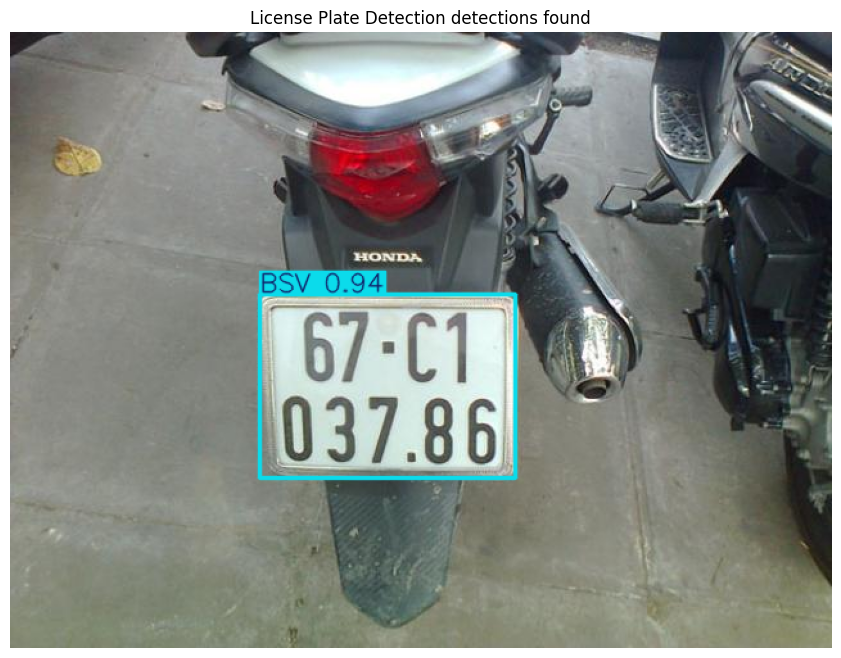


Detections found: 1
Detection 1:
  Class: BSV
  Confidence: 0.936
  Bounding box: [194, 204, 393, 347]


In [4]:
import matplotlib.pyplot as plt
# Input image
img_file = "./image_video/test/xemayBigPlate94_jpg.rf.657c42d7da606b6968b51b407ffc6742.jpg"
img = cv2.imread(img_file)
test_images=img_file 
# Detect license plates
plates = yolo_LP_detect.predict(source=img, imgsz=640, conf=conf_thres)

list_read_plates = set()
count = 0
if test_images:
        test_image_path = test_images
        print(f"Testing với ảnh: {test_image_path}")
        
        # Detect
        annotated_img, detections = detect_license_plate(test_image_path)
        
        if annotated_img is not None:
            # Hiển thị kết quả
            plt.figure(figsize=(12, 8))
            plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
            plt.title(f"License Plate Detection detections found")
            plt.axis('off')
            plt.show()
            
            # In thông tin detections
            print(f"\nDetections found: {len(detections)}")
            for i, det in enumerate(detections):
                print(f"Detection {i+1}:")
                print(f"  Class: {det['class']}")
                print(f"  Confidence: {det['confidence']:.3f}")
                print(f"  Bounding box: {det['bbox']}")
        else:
            print("Không tìm thấy ảnh test")
else:
        print("Không có ảnh trong validation set")

In [5]:

if len(plates) > 0:
    # Lấy đối tượng Results đầu tiên
    result = plates[0]
    
    # Trích xuất dữ liệu và tạo DataFrame
    list_plates = pd.DataFrame(result.boxes.data.tolist(), columns=["xmin", "ymin", "xmax", "ymax", "confidence", "class_id"])
    list_plates = list_plates.values.tolist()
else:
    list_plates = []



for plate in list_plates:
    flag = 0
    x = int(plate[0])  # xmin
    y = int(plate[1])  # ymin
    w = int(plate[2] - plate[0])  # xmax - xmin
    h = int(plate[3] - plate[1])  # ymax - ymin
    cls_id = plate[5]
    # Đảm bảo kích thước crop hợp lệ
    if w <= 0 or h <= 0:
        continue
        
    crop_img = img[y:y + h, x:x + w]
    cv2.rectangle(img, (int(plate[0]), int(plate[1])), (int(plate[2]), int(plate[3])), color=(0, 0, 225), thickness=2)
    cv2.imwrite("crop.jpg", crop_img)
    rc_image = cv2.imread("crop.jpg")
    flag = 0
    lp = ""
    # count += 1
    
    
    for cc in range(0, 2):
        for ct in range(0, 2):
            # Deskew ảnh
            deskewed_img = utils_rotate.deskew(crop_img, cc, ct)

            # OCR bằng helper mới (pytesseract)
            lp = helper.read_plate_from_crop(deskewed_img, is_two_lines=(cls_id == 1))

            # Nếu đọc được -> lưu vào set
            if lp and lp != "unknown":
                list_read_plates.add(lp)
                flag = 1
                break
        if flag == 1:
            break



        

/Users/hoangtranminh/Documents/python/model_dectect/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


biển số xe là : 67-C103786


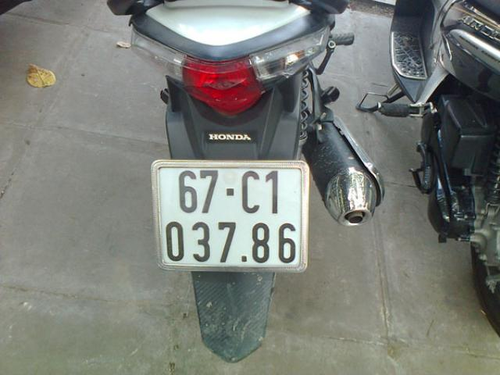

In [6]:
print(f"biển số xe là : {lp}")
img = Image.open(img_file)
basewidth = 500
wpercent = (basewidth/float(img.size[0]))
hsize = int((float(img.size[1])*float(wpercent)))
img = img.resize((basewidth, hsize), Image.LANCZOS)
display(img)